In [1]:
import kagglehub

/home/odi/repo/ml_study/pandas_study/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

# Download latest version
path = kagglehub.dataset_download("yasserh/nyc-taxi-trip-duration")

print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /home/odi/.cache/kagglehub/datasets/yasserh/nyc-taxi-trip-duration/versions/1
['NYC.csv']


In [3]:
import pandas as pd

df = pd.read_csv(f"{path}/NYC.csv")

## 1. Data Dictionary

Before exploring the data, each column is documented with: its real-world meaning, its pandas dtype vs. its semantic type, whether it would actually be available at the moment a prediction needs to be made (i.e., before the trip is over), and whether it's usable as a feature.

**Availability rule**: a column is usable as a feature only if it exists and is known *before* `trip_duration` can be determined — before the trip ends. Anything that only exists once the trip is complete is discarded, even if it correlates strongly with the target (that correlation is exactly what makes it dangerous to keep).

| Column | Real-world meaning | Pandas dtype (semantic type) | Available before `trip_duration` exists? | Classification |
|---|---|---|---|---|
| `id` | Unique identifier of the trip record | `str` (arbitrary identifier) | Yes | **Excluded** — not leakage, just zero predictive value: every value is unique, so a model can't generalize from it to trips it hasn't seen |
| `vendor_id` | Code identifying the provider associated with the trip record | `int64` (semantically categorical) | Yes | **Feature** |
| `pickup_datetime` | Date and time when the meter was engaged | `str` (needs parsing into `datetime`) | Yes | **Feature** — needs decomposition (hour/day/month) before modeling |
| `dropoff_datetime` | Date and time when the meter was disengaged | `str` (needs parsing into `datetime`) | **No** — `trip_duration = dropoff_datetime - pickup_datetime`, so this column directly encodes the target | **Excluded — leakage** |
| `passenger_count` | Number of passengers during the trip | `int64` | Yes | **Feature** |
| `pickup_longitude`, `pickup_latitude` | Coordinates where the meter was engaged | `float64` (semantically geospatial) | Yes | **Feature** |
| `dropoff_longitude`, `dropoff_latitude` | Coordinates where the meter was disengaged | `float64` (geospatial) | **No** — captured at the exact moment the trip ends, the same mechanism as `dropoff_datetime` | **Excluded — leakage** |
| `store_and_fwd_flag` | Whether the trip record was held in the vehicle's memory before being sent to the vendor, because the vehicle had no connection to the server (`Y`/`N`) | `str` (semantically boolean) | **No** — its value can only be known once a complete trip record exists to transmit, which requires the trip to be over | **Excluded — leakage** (data-availability leakage: unlike the dropoff columns, this flag has no causal link to duration, so it wouldn't inflate performance — the problem here is purely that it doesn't exist yet at prediction time) |
| `trip_duration` | Trip duration, in seconds | `int64` | — | **Target** |

**Features going forward**: `vendor_id`, `pickup_datetime`, `passenger_count`, `pickup_longitude`, `pickup_latitude`.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [ ]:
df.groupby('vendor_id').agg({
    'vendor_id': ['min', 'max', 'mean']
})

In [ ]:
df.sample(20)

In [ ]:
# FEATURES TO USE

#vendor_id
#pickup_datetime
#passenger_count
#pickup_longitude
#pickup_latitude

df.describe()

In [5]:
df = df.drop(['id'], axis=1)
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1458639    False
1458640    False
1458641    False
1458642    False
1458643    False
Length: 1458644, dtype: bool

## 3. Distribution — technique varies by column type

Goal: for each column (or group of columns), understand the shape of the distribution (symmetric? skewed with a long tail?), central tendency/dispersion, and cardinality (for categorical columns). What you find here directly feeds section 4 (outliers) and the feature engineering decisions further down the pipeline.

Groups to analyze:
- **3.1 Continuous numerical**: `trip_duration` (target), `pickup_longitude`, `pickup_latitude`
- **3.2 Low-cardinality categorical**: `vendor_id`, `store_and_fwd_flag`
- **3.3 Discrete numerical**: `passenger_count`
- **3.4 Datetime**: `pickup_datetime`
- **3.5 Geospatial (bivariate)**: `pickup_longitude` × `pickup_latitude`

Document your conclusions in each block before moving to the next.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

### Helper functions

Reusable plotting/summary functions, parameterized by column name, so the same logic applies to any column instead of being duplicated per column.

In [7]:
def plot_continuous_distribution(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[column], kde=True, ax=axes[0])
    sns.boxplot(x=df[column], ax=axes[1])
    fig.suptitle(column)
    plt.show()

    print(df[column].describe())
    print(f"skew: {df[column].skew()}")


def plot_categorical_distribution(df, column):
    counts = df[column].value_counts()
    proportions = df[column].value_counts(normalize=True)

    print(counts)
    print(proportions)

    sns.barplot(x=counts.index, y=counts.values)
    plt.title(column)
    plt.show()


def plot_datetime_components(df, column):
    dt = pd.to_datetime(df[column])
    components = {
        "hour": dt.dt.hour,
        "dayofweek": dt.dt.dayofweek,
        "month": dt.dt.month,
    }

    for name, series in components.items():
        counts = series.value_counts().sort_index()
        print(f"{column} - {name}")
        print(counts)

        sns.barplot(x=counts.index, y=counts.values)
        plt.title(f"{column} - {name}")
        plt.show()


def plot_geo_scatter(df, lon_column, lat_column, sample_size=50000, random_state=42):
    sample = df.sample(sample_size, random_state=random_state)

    plt.figure(figsize=(8, 8))
    plt.scatter(sample[lon_column], sample[lat_column], s=1, alpha=0.3)
    plt.xlabel(lon_column)
    plt.ylabel(lat_column)
    plt.show()

### 3.1 Continuous numerical

**Techniques**: histogram + KDE, boxplot, `.describe()`, `.skew()`.

**Guiding questions**:
- Is the distribution symmetric, or does it have a long tail (skewed)?
- Where is most of the mass concentrated?
- Does the boxplot already suggest outliers? (this gets a deeper look in section 4 — here it's just the first signal)
- For `trip_duration`: does the shape hint at a transformation (e.g., log) or at which evaluation metric will make more sense later on?

**Conclusions:** _(fill in after running the cell below, once per column in the group)_

In [ ]:
for column in ["trip_duration", "pickup_longitude", "pickup_latitude"]:
    plot_continuous_distribution(df, column)

### 3.2 Low-cardinality categorical

**Techniques**: `.value_counts()`, `.value_counts(normalize=True)` (proportions), bar chart.

**Guiding questions**:
- How many categories actually exist?
- Are the classes balanced, or does one dominate almost entirely?
- Does a very rare/dominant class change how this column should be treated further down the pipeline (e.g., for modeling, or for a keep/drop decision)?

**Conclusions:** _(fill in after running the cell below, once per column in the group)_

In [ ]:
for column in ["vendor_id", "store_and_fwd_flag"]:
    plot_categorical_distribution(df, column)

### 3.3 Discrete numerical — `passenger_count`

Sits between the two worlds: numerical, but with only a handful of possible values. Worth looking at it both as `value_counts()` (how many trips have 0, 1, 2... passengers) and as a numerical distribution (`.describe()`, histogram, skew) — reusing the same two functions defined above.

**Guiding question**: is there any value that doesn't make physical sense for a passenger car? (keep this for section 4, on outliers)

**Conclusions:** _(fill in after running the cells below)_

In [ ]:
plot_continuous_distribution(df, "passenger_count")

In [ ]:
plot_categorical_distribution(df, "passenger_count")

### 3.4 Datetime — `pickup_datetime`

The raw column (string) doesn't go directly into a histogram — first it needs to be parsed and decomposed into components (hour, day of week, month) via `pd.to_datetime()` and the `.dt` accessor. The decomposition done here is local to the analysis and doesn't mutate `df`; the columns actually used for modeling get created later, in feature engineering.

**Guiding questions**:
- Is there a pattern by hour of day (demand peaks)?
- Is there a pattern by day of week?
- How much time does the dataset cover (how many months)? This matters for the train/test split decision later on.

**Conclusions:** _(fill in after running the cell below)_

In [ ]:
plot_datetime_components(df, "pickup_datetime")

### 3.5 Geospatial (bivariate) — `pickup_longitude` × `pickup_latitude`

Coordinates in isolation (e.g., a histogram of longitude alone) don't say much on their own. A scatter plot of longitude × latitude together shows the actual geographic shape of the pickups, and helps spot points that fall outside the expected area (also useful for section 4). Since the dataset is large, a sample (`df.sample(n=...)`) keeps the plot from choking.

**Guiding question**: do the points trace a recognizable shape (the city)? Are there isolated points, far from the rest?

**Conclusions:** _(fill in after running the cell below)_

In [ ]:
plot_geo_scatter(df, "pickup_longitude", "pickup_latitude")

### 4. Data cleaning


### 4.1 `trip_duration` — bounds


**Approach**: domain-based bounds instead of a statistical formula.
- **Lower bound — 60s**: a trip under a minute (the dataset's min was 1 second) isn't a real ride — meter/GPS error or an immediately-cancelled trip.
- **Upper bound — 3h (10800s)**: per NYC TLC trip data, in-city taxi rides longer than ~3 hours fall outside the realistic range. The dataset's max (~40.8 days) is clearly corrupted data, not an unusually long trip.

**Conclusions**: 8,595 rows removed below 60s (0.59%) and 2,112 rows above 3h (0.15%) — 10,707 rows total, 0.73% of the dataset. The remaining 1,447,937 rows (99.27%) fall within a physically plausible range for a taxi trip.

In [8]:

print(df.trip_duration.describe().apply(lambda x : f"{x:,.0f}"))


print("Lower bound trip duration:")
for t in [1, 10, 30, 60, 120]:
    print(t, (df.trip_duration < t).sum())



print("Upper bound trip duration:")
THREE_HOURS = 3 * 60 * 60  # 10800
(df.trip_duration > THREE_HOURS).sum()


LOWER_BOUND = 60
UPPER_BOUND = 3 * 60 * 60

df = df[(df.trip_duration >= LOWER_BOUND) & (df.trip_duration <= UPPER_BOUND)]

print(df.trip_duration.describe().apply(lambda x : f"{x:,.0f}"))





count    1,458,644
mean           959
std          5,237
min              1
25%            397
50%            662
75%          1,075
max      3,526,282
Name: trip_duration, dtype: str
Lower bound trip duration:
1 0
10 1984
30 4782
60 8595
120 27817
Upper bound trip duration:
count    1,447,937
mean           842
std            657
min             60
25%            401
50%            665
75%          1,076
max         10,731
Name: trip_duration, dtype: str


#### 4.2 `passenger_count` — bounds

**`passenger_count == 0`**: logically impossible — a taxi fare requires at least one passenger. Unlike the `trip_duration` outliers, this isn't a matter of degree; it's a value the real world can't produce for this dataset, so it's dropped regardless of how many rows are affected.

**`passenger_count > 6`**: different reasoning than the zero case. A value like 7, 8, or 9 isn't logically impossible — vehicles licensed for more than 6 passengers exist — but with only 1-2 rows at each of these values, there's no statistical basis to trust the data point (could be a legitimate large vehicle or a data entry error, and there's no way to tell from a single row). `6` is kept as the upper bound because it has real volume (48,034 rows) and matches a physically common vehicle type (7-seater: driver + 6).



In [9]:
max_passengers_count = 6
min_passengers_count = 1


df = df[(df.passenger_count <= max_passengers_count) & (df.passenger_count >= min_passengers_count)]


#### 4.3 `pickup_longitude` / `pickup_latitude` — bounds

**Rationale**: this is a NYC taxi dataset, so pickups should cluster tightly around the city. The distribution stats already showed this (very small `std`: ~0.07° longitude, ~0.03° latitude) alongside `min`/`max` that are geographically absurd for the context — longitude ranging to -121° (California) and latitude to 51° (Canada). No NYC taxi picks up a fare there; these are GPS/logging errors, not real trips.

**Why not a statistical formula**: same issue as `trip_duration` — with `std` this small relative to the min/max spread, a formula-based cutoff (e.g. `mean ± k*std`) would either barely trim anything or be dominated by the very outliers it's meant to detect.

**Method**: threshold sweep, same approach as `trip_duration` — count rows outside each candidate cutoff and look for the point where the count jumps abruptly from a small residual tail into a dense cluster. That jump marks the boundary between error and real data:

| axis | just outside bound | count | just inside | count | jump |
|---|---|---|---|---|---|
| longitude (west) | < -74.02 | 780 (0.05%) | < -74.01 | 33,959 (2.33%) | ~43x |
| longitude (east) | > -73.75 | 211 (0.01%) | > -73.78 | 6,780 (0.47%) | ~32x |
| latitude (south) | < 40.64 | 638 (0.04%) | < 40.65 | 32,361 (2.22%) | ~50x |
| latitude (north) | > 40.85 | 1,011 (0.07%) | > 40.80 | 28,124 (1.93%) | ~28x |

**Bounds**:
```python
LON_BOUNDS = (-74.03, -73.75)
LAT_BOUNDS = (40.63, 40.85)


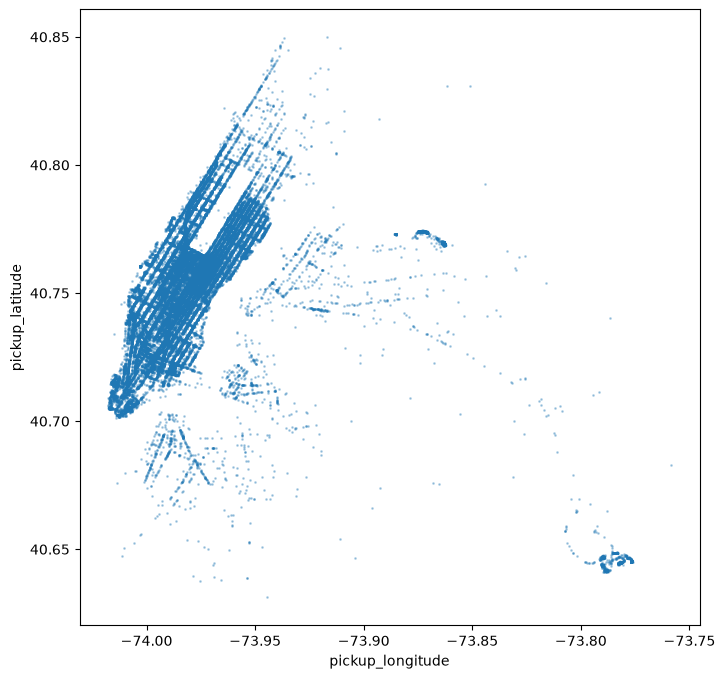

In [10]:
LON_BOUNDS = (-74.03, -73.75)
LAT_BOUNDS = (40.63, 40.85)

df = df[
    df.pickup_longitude.between(*LON_BOUNDS) &
    df.pickup_latitude.between(*LAT_BOUNDS)
]
plot_geo_scatter(df, "pickup_longitude", "pickup_latitude")

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1446418 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1446418 non-null  int64  
 1   pickup_datetime     1446418 non-null  str    
 2   dropoff_datetime    1446418 non-null  str    
 3   passenger_count     1446418 non-null  int64  
 4   pickup_longitude    1446418 non-null  float64
 5   pickup_latitude     1446418 non-null  float64
 6   dropoff_longitude   1446418 non-null  float64
 7   dropoff_latitude    1446418 non-null  float64
 8   store_and_fwd_flag  1446418 non-null  str    
 9   trip_duration       1446418 non-null  int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 121.4 MB


### Data Engineer

#### 5.1 `vendor_id` — one-hot encoding

**Rationale**: `vendor_id` is stored as `int64`, but the values `1` and `2` are nominal labels (which taxi provider), not a magnitude — there's no sense in which provider "2" is greater than provider "1". Leaving it as a raw integer risks models that assume numeric/ordinal meaning (linear regression, KNN, distance-based methods) learning a false ordering between categories.

**Method**: `OneHotEncoder` (scikit-learn) instead of `pd.get_dummies`, so the encoding can later be `fit` on train and `transform` on test without silently producing mismatched columns if a category is missing from one split. `handle_unknown="ignore"` protects against a category appearing at transform time that wasn't seen at fit time. `drop="if_binary"` drops one of the two generated columns specifically because this feature has exactly 2 categories — keeping both would be redundant (one is always `1 - other`), so a single binary column carries the full information without the redundancy.

**Result**: `vendor_id` (1 or 2) is replaced by a single column, `vendor_id_2` — `1` when the provider is vendor 2, `0` when it's vendor 1.


In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="if_binary")

encoded_values = encoder.fit_transform(df[["vendor_id"]])
new_cols = encoder.get_feature_names_out(["vendor_id"])

df_encoded = pd.DataFrame(encoded_values, columns=new_cols, index=df.index)


df = pd.concat([df.drop(columns=['vendor_id']), df_encoded], axis=1)




In [ ]:
df.info()

#### 5.2 `pickup_datetime` — decomposition

**Rationale**: `pickup_datetime` arrives as `str`, which has no notion of hour/weekday. Converting to `datetime64` via `pd.to_datetime()` unlocks the `.dt` accessor, needed to derive time-based features.

**Which components to extract**: decided based on what the dataset's own date range supports, not just what's technically extractable.

- **`pickup_hour`**: kept — the strongest expected signal for this problem. NYC traffic has well-documented rush-hour patterns (morning/evening peaks vs. off-hours), and trip duration for the same distance can vary heavily by hour.
- **`pickup_dayofweek`**: kept — captures the weekday vs. weekend traffic difference.
- **`year`**: excluded — the dataset covers only 2016-01-01 to 2016-06-30, a single year. A constant column carries zero information and would never generalize to a different year.
- **`month`**: excluded for now — same range issue on a smaller scale: only 6 consecutive months, no way to observe a full seasonal cycle (no fall/winter comparison).
- **`minute`, `day of year`, `week of year`, `week of month`**: excluded — no domain mechanism ties trip duration to this level of granularity (traffic doesn't shift meaningfully minute-to-minute), and these overlap heavily with `hour`/`pickup_dayofweek`/`month`, adding cardinality and redundancy without new signal.

**Method**: `.dt.hour` / `.dt.dayofweek` (vectorized), not `.apply(lambda x: ...)` — on 1.4M rows the vectorized accessor is roughly 65x faster and produces identical results.

**Note for later**: `pickup_hour` and `pickup_dayofweek` are cyclical (hour 23 is adjacent to hour 0; Sunday is adjacent to Monday). If a magnitude-sensitive model (linear regression, KNN) is used downstream, revisit with sin/cos cyclical encoding — not needed for tree-based models.


In [13]:

df.pickup_datetime = pd.to_datetime(df.pickup_datetime)

df['pickup_hour'] = df.pickup_datetime.dt.hour
df['pickup_dayofweek'] = df.pickup_datetime.dt.dayofweek


### 6. Split Data

**Feature matrix (`X`)**: built only from the columns validated as real features, free of leakage — `passenger_count`, `pickup_longitude`, `pickup_latitude`, `vendor_id_2`, `pickup_hour`, `pickup_dayofweek`. Explicitly excludes `id`, `dropoff_datetime`, `dropoff_longitude`, `dropoff_latitude`, `store_and_fwd_flag` (leakage, per the data dictionary in section 1) and the raw `pickup_datetime` (already decomposed into `pickup_hour`/`pickup_dayofweek` in 5.2, and not usable directly by most models anyway).

**Target (`y`)**: `np.log1p(trip_duration)`, not the raw value. After cleaning, `trip_duration` still has skew ≈ 2.32; `log1p` brings it to ≈ -0.13 (near-symmetric). Applied before the split, not after — `log1p` is a deterministic, per-row transform with no data-dependent parameters (unlike scaling or clustering), so it carries no leakage risk regardless of when it's applied.

**Split**: `train_test_split(X, y, test_size=0.2, random_state=42)`. `shuffle=True` (the default) is appropriate here — this isn't a forecasting task where train must precede test in time; the goal is predicting duration for an arbitrary unseen trip within the same period, and `pickup_hour`/`pickup_dayofweek` patterns are stable across the whole Jan–Jun 2016 window rather than trending. `random_state=42` fixes the split so results are reproducible across reruns.

**Caveat carried into the next step**: a single train/test split is enough to train and evaluate *one* model. It gets weaker the moment several candidate models are compared against `X_test`/`y_test` and the best one is picked from that comparison — the selection decision itself "sees" the test set indirectly, even though no weights were fit on it. The more rigorous setup is to compare candidates via cross-validation on `X_train`/`y_train` (or a validation split carved out of train), keeping `X_test` untouched for a single, final check on whichever model wins.


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

FEATURES = ["passenger_count", "pickup_longitude", "pickup_latitude", "vendor_id_2", "pickup_hour", "pickup_dayofweek"]
X = df[FEATURES]
y = np.log1p(df["trip_duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





In [15]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]),
    "DecisionTree": Pipeline([
        ("model", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ]),
    "HistGradientBoosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds_log = pipeline.predict(X_test)

    rmsle = root_mean_squared_error(y_test, preds_log)  # y_test e preds já em log -> isso já É o RMSLE

    preds_seconds = np.expm1(preds_log)
    y_test_seconds = np.expm1(y_test)
    mae_minutes = mean_absolute_error(y_test_seconds, preds_seconds) / 60

    results.append({"model": name, "RMSLE": rmsle, "MAE_minutos": mae_minutes})

results_df = pd.DataFrame(results).sort_values("RMSLE")
results_df




,model,RMSLE,MAE_minutos
4,HistGradientBoosting,0.661651,6.464578
3,RandomForest,0.664599,6.479019
2,DecisionTree,0.666812,6.498886
0,LinearRegression,0.694227,6.916044
1,Ridge,0.694227,6.916044
